In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy

In [143]:
import warnings 
warnings.filterwarnings("ignore")

In [144]:
data = pd.read_csv('Country-data (1).csv')

### Explanation of Data

- **country**: Name of the country
- **child_mort**: Death of children under 5 years of age per 1000 live births
- **exports**: Exports of goods and services per capita (percentage of GDP per capita)
- **health**: Total health spending per capita (percentage of GDP per capita)
- **imports**: Imports of goods and services per capita (percentage of GDP per capita)
- **Income**: Net income per person
- **Inflation**: Annual growth rate of the Total GDP
- **life_expec**: Average lifespan if current mortality patterns remain the same
- **total_fer**: Number of children born per woman if current age-fertility rates remain
- **gdpp**: GDP per capita (Total GDP divided by total population)


In [145]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [146]:
df = copy.deepcopy(data)
df.head(25)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [147]:
df.head(25).tail(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
20,Bosnia and Herzegovina,6.9,29.7,11.10,51.3,9720,1.40,76.8,1.31,4610
21,Botswana,52.5,43.6,8.30,51.3,13300,8.92,57.1,2.88,6350
22,Brazil,19.8,10.7,9.01,11.8,14500,8.41,74.2,1.80,11200
23,Brunei,10.5,67.4,2.84,28.0,80600,16.70,77.1,1.84,35300
24,Bulgaria,10.8,50.2,6.87,53.0,15300,1.11,73.9,1.57,6840


In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [149]:
df.nunique()

country       167
child_mort    139
exports       147
health        147
imports       151
income        156
inflation     156
life_expec    127
total_fer     138
gdpp          157
dtype: int64

In [150]:
df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [151]:
df.shape

(167, 10)

In [152]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


### scaling is important.

### outlier handling can be doing, but each row is important and they will be clustered at last. That’s why, you can’t throw any row away


# Corellation

In [153]:
df_corr=df.drop('country',axis=1).copy()

In [154]:
df_corr.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


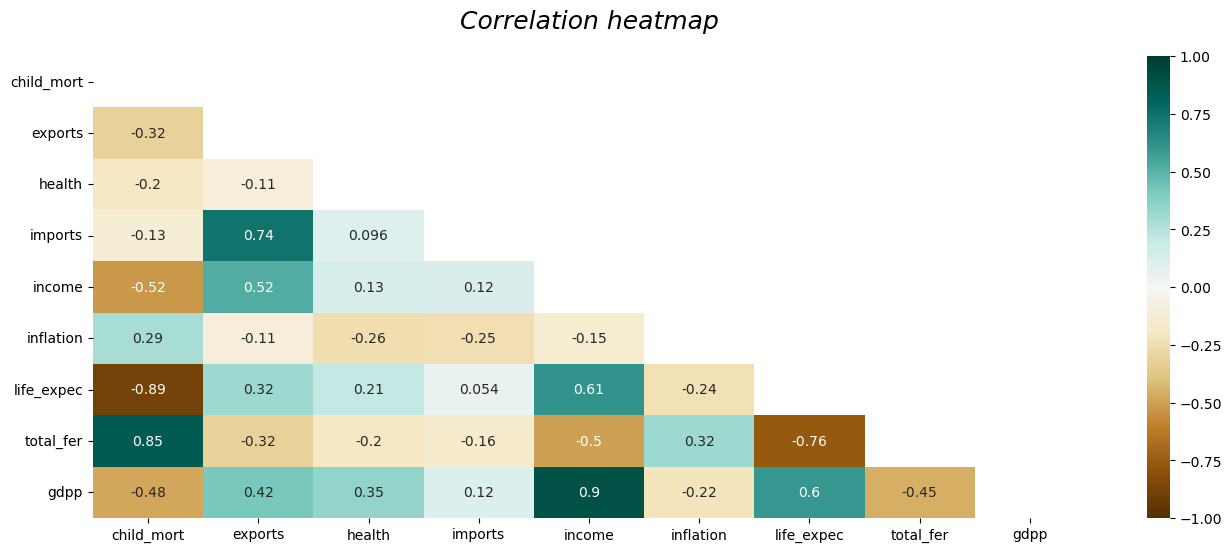

In [155]:
plt.figure(figsize=(16, 6))

mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))

heatmap = sns.heatmap(
    df_corr.corr(),
    mask=mask,
    vmin=-1,
    vmax=1,
    annot=True,
    cmap='BrBG'
)

heatmap.set_title(
    'Correlation heatmap',
    fontdict={'fontsize': 18, 'fontstyle': 'italic'},
    pad=20
)

plt.show()


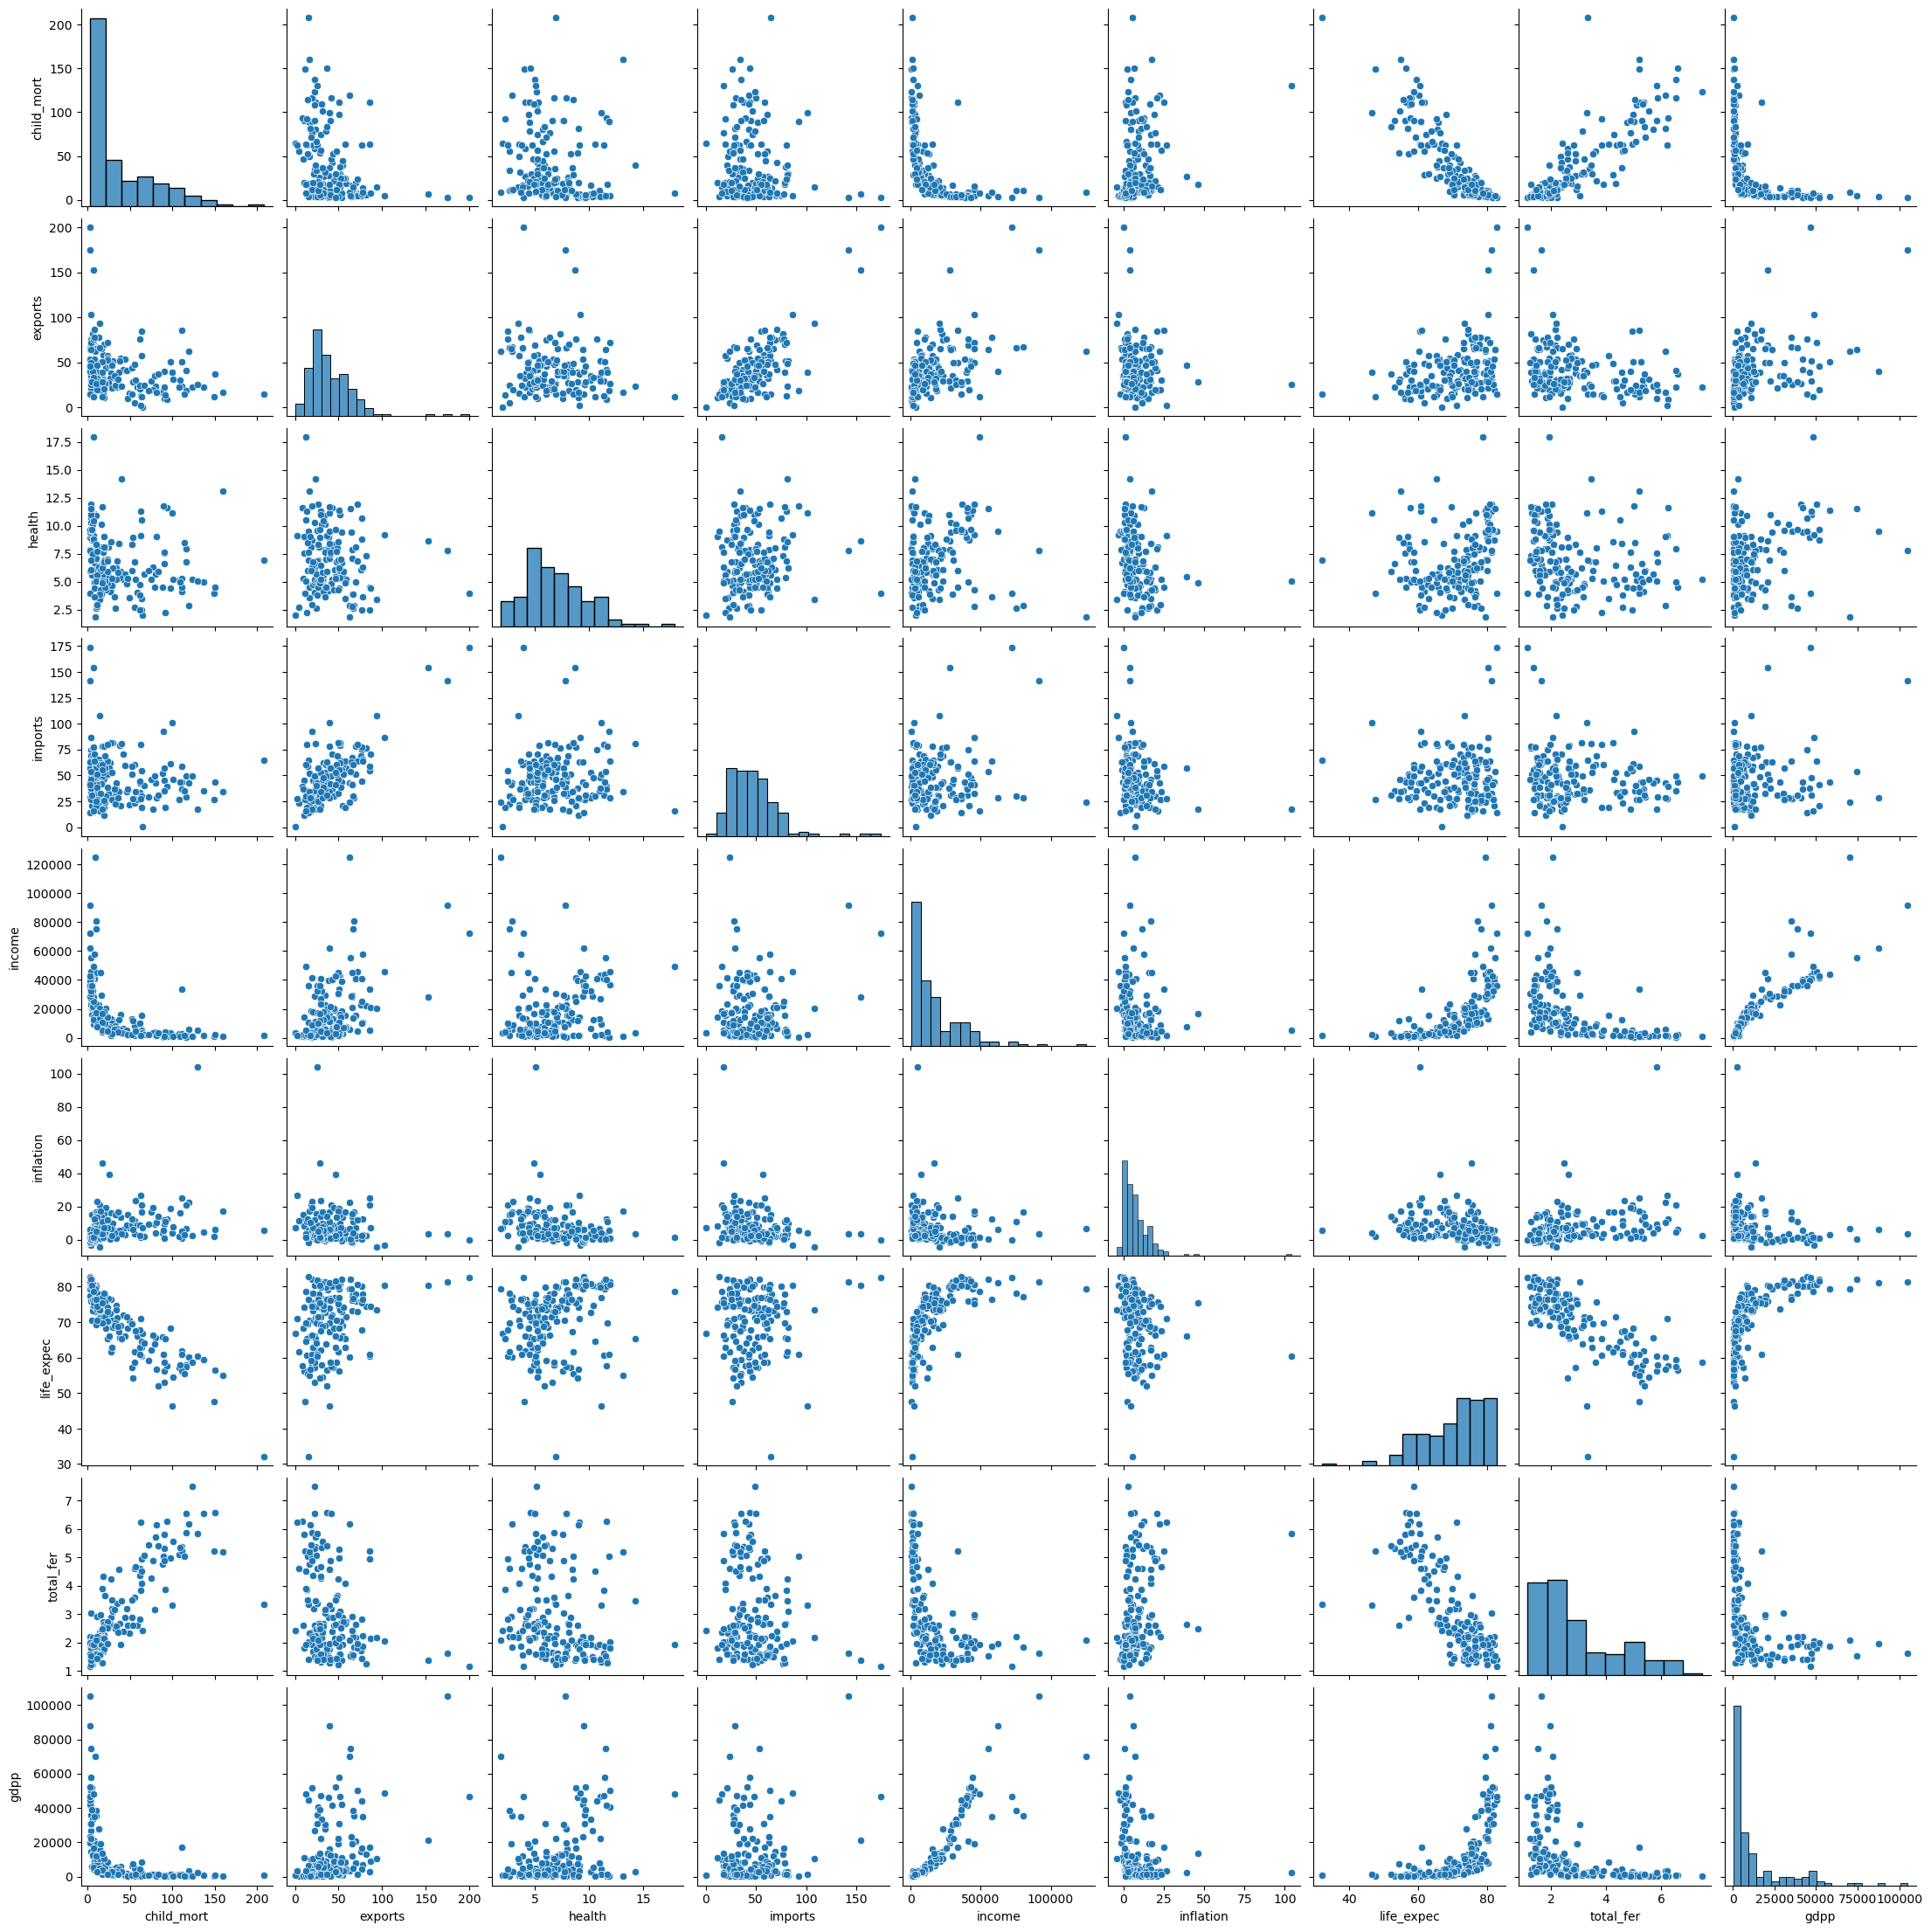

In [156]:
sns.pairplot(df_corr)
plt.show()

In [157]:
df.set_index('country', inplace=True)
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [158]:
df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310


### Outliers check

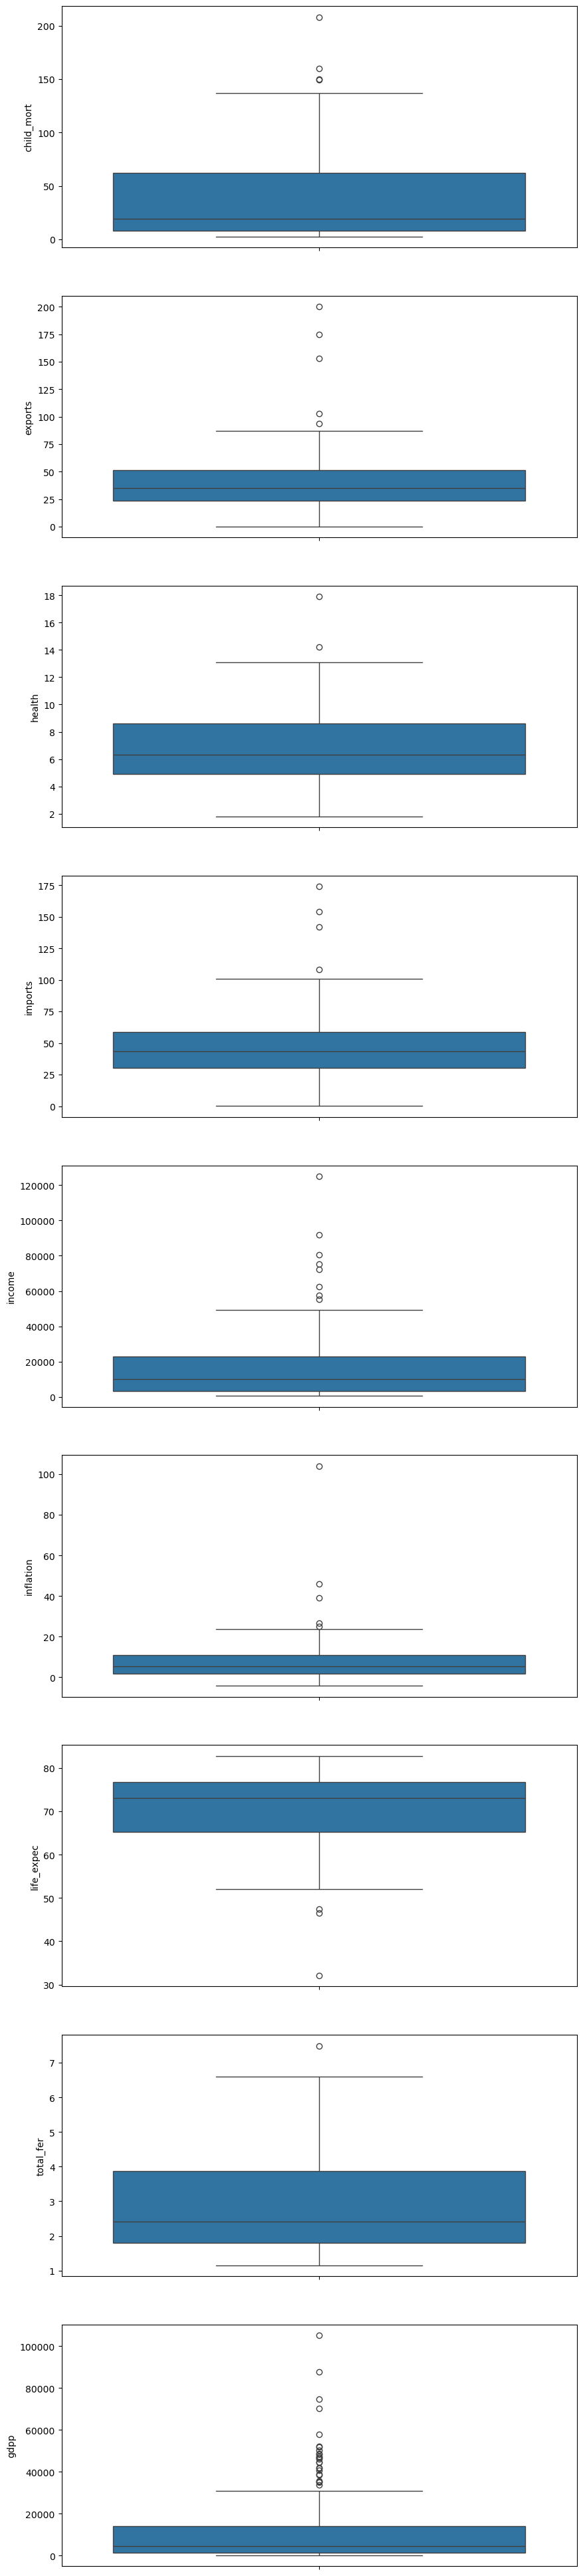

In [159]:
fig, axes = plt.subplots(nrows=len(df.columns), figsize=(10, 50))
for i in range(len(df.columns)):
    sns.boxplot(ax=axes[i], y=df.columns[i], data=df )

In [160]:
def boxplot_clip(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower_bound, upper_bound)


In [161]:
for i in df.columns:
    boxplot_clip(i)   

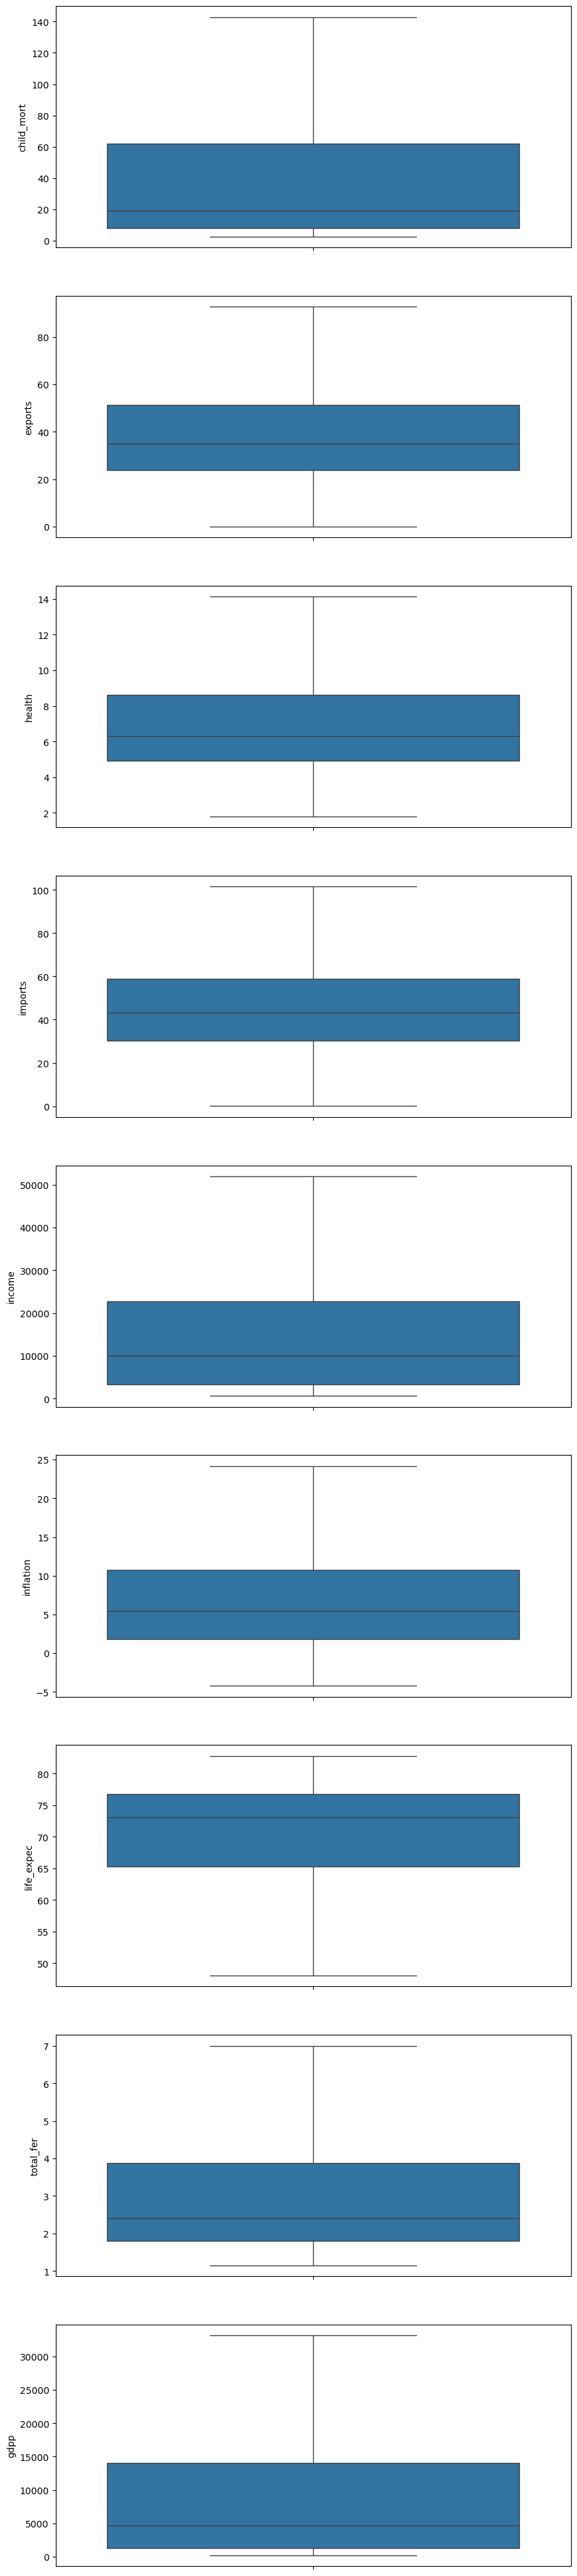

In [162]:
fig, axes = plt.subplots(nrows=len(df.columns), figsize=(10, 50))
for i in range(len(df.columns)):
    sns.boxplot(ax=axes[i], y=df.columns[i], data=df)

In [163]:
df.shape

(167, 9)

### Scaling

In [164]:
df_=copy.deepcopy(df)

In [165]:
df_.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610.0,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930.0,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900.0,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900.0,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100.0,1.44,76.8,2.13,12200


In [166]:
from sklearn.preprocessing import StandardScaler # Other Scaling Methods: Min-Max,Robust, MaxAbsScaler, Unit Vector and etc.
column_names = df.columns
index_names = data.country
s = StandardScaler()
df = s.fit_transform(df)
df = pd.DataFrame(df, index=index_names, columns=column_names)

In [167]:
data.country

0              Afghanistan
1                  Albania
2                  Algeria
3                   Angola
4      Antigua and Barbuda
              ...         
162                Vanuatu
163              Venezuela
164                Vietnam
165                  Yemen
166                 Zambia
Name: country, Length: 167, dtype: object

In [168]:
df

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,1.369802,-1.391107,0.296013,-0.047444,-0.943936,0.355270,-1.702225,1.915276,-0.846341
Albania,-0.550464,-0.543547,-0.091190,0.135021,-0.395181,-0.385208,0.663321,-0.862779,-0.540827
Algeria,-0.271295,-0.053846,-0.985893,-0.713196,-0.199291,1.351551,0.686859,-0.036691,-0.508868
Angola,2.121210,1.071524,-1.482114,-0.146074,-0.660984,2.293979,-1.243238,2.141784,-0.589198
Antigua and Barbuda,-0.714835,0.280469,-0.286671,0.642965,0.209637,-0.841463,0.722166,-0.543003,0.159686
...,...,...,...,...,...,...,...,...,...
Vanuatu,-0.221723,0.332264,-0.579893,0.337212,-0.855555,-0.664945,-0.901941,0.369691,-0.637569
Venezuela,-0.537419,-0.520004,-0.707708,-1.393742,0.038151,2.557260,0.557401,-0.316495,0.271975
Vietnam,-0.375657,1.528265,0.017828,1.693373,-0.753982,0.753184,0.286717,-0.662919,-0.780954


In [169]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,-2.127373e-17,1.003008,-0.915732,-0.768320,-0.480020,0.636657,2.744123
exports,167.0,1.329608e-16,1.003008,-1.856841,-0.741311,-0.213941,0.555926,2.501781
health,167.0,1.555642e-16,1.003008,-1.873076,-0.703948,-0.177653,0.679457,2.754565
imports,167.0,1.276424e-16,1.003008,-2.258436,-0.772374,-0.126348,0.635567,2.747480
income,167.0,6.648042e-19,1.003008,-1.009958,-0.828842,-0.393202,0.453674,2.377449
inflation,167.0,-3.191060e-17,1.003008,-1.686656,-0.786114,-0.250576,0.551236,2.557260
life_expec,167.0,9.001449e-16,1.003008,-2.661389,-0.631256,0.286717,0.722166,1.428299
total_fer,167.0,3.815976e-16,1.003008,-1.195879,-0.766180,-0.356467,0.622847,2.706389
gdpp,167.0,2.127373e-17,1.003008,-0.874154,-0.779227,-0.491593,0.319482,1.967546


Insights that have done:

outlier handlings each row is important and they will be clustered at last. That’s why, you can’t drop any row - DONE

scaling is important - DONE


# Clustering with K-Means
### Silhouette or Elbow?

In [170]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=3, random_state=42)
k_means.fit(df)


KMeans(n_clusters=3, random_state=42)

In [171]:
k_means


KMeans(n_clusters=3, random_state=42)

In [172]:
k_means.labels_


array([0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 1, 2, 0, 2, 2, 2, 2, 0, 0, 0, 1, 0,
       1, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 2, 2,
       1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 2, 1, 0, 0, 0, 0, 2, 1, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0,
       0, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 2, 0, 2, 0, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 1, 2,
       0, 2, 2, 2, 0, 0, 2, 1, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 0, 0, 2, 1,
       0, 0, 0, 2, 1, 1, 1, 0, 0, 0, 2, 0, 0], dtype=int32)

In [173]:
df_final = copy.deepcopy(data)

In [174]:
df_final.set_index("country", inplace=True)

In [175]:
df_final['k_means_cluster'] = k_means.labels_

In [176]:
df_final.head(25)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster
country,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,0
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0
Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,0
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,2
Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0
Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,1


# Meaning of numbers
Which number is Developed, Developing, and Under-developed? Ourselves

In [177]:
df_final[df_final['k_means_cluster'] == 0].head()
# 0 - developed

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster
country,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300,0


In [178]:
df_final[df_final['k_means_cluster'] == 1].head()
# 1 - underdeveloped

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster
country,,,,,,,,,,
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,1
Bahamas,13.8,35.0,7.89,43.7,22900,-0.393,73.8,1.86,28000,1
Bosnia and Herzegovina,6.9,29.7,11.10,51.3,9720,1.400,76.8,1.31,4610,1
Brazil,19.8,10.7,9.01,11.8,14500,8.410,74.2,1.80,11200,1


In [179]:
df_final[df_final['k_means_cluster'] == 2].head()
# 2  - developing

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster
country,,,,,,,,,,
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,2
Bahrain,8.6,69.5,4.97,50.9,41100,7.440,76.0,2.16,20700,2
Barbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000,2
Belarus,5.5,51.4,5.61,64.5,16200,15.100,70.4,1.49,6030,2
Belgium,4.5,76.4,10.70,74.7,41100,1.880,80.0,1.86,44400,2


In [180]:
df_final.k_means_cluster.replace({0: 'underdeveloped',
                                  1: 'developed',
                                  2: 'developing'}, inplace=True)

In [181]:
df_final.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster
country,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,underdeveloped
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,underdeveloped
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,developing


In [182]:
df_final.k_means_cluster.value_counts()

k_means_cluster
underdeveloped    97
developing        40
developed         30
Name: count, dtype: int64

## Hierarchical Agglomerative Clustering

In [183]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
hc_clusters = hc.fit_predict(df)

In [184]:
hc_clusters

array([2, 1, 1, 2, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1,
       1, 0, 0, 2, 2, 0, 2, 0, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 2, 0, 0, 0,
       0, 1, 1, 1, 1, 2, 1, 0, 0, 0, 0, 1, 1, 1, 0, 2, 0, 1, 1, 2, 2, 0,
       2, 0, 0, 1, 1, 1, 2, 0, 0, 0, 1, 0, 0, 1, 1, 2, 0, 0, 1, 0, 0, 2,
       2, 0, 0, 0, 0, 1, 2, 0, 0, 2, 0, 2, 0, 2, 1, 1, 0, 1, 2, 1, 1, 1,
       0, 0, 2, 2, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 1, 0,
       2, 0, 0, 0, 0, 1, 0, 0, 1, 1, 2, 1, 0, 0, 1, 1, 0, 2, 2, 1, 0, 1,
       0, 2, 1, 0, 0, 0, 1, 1, 0, 1, 0, 2, 2])

In [185]:
df_final['hc_cluster'] = hc_clusters

In [186]:
df_final.head(25)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster
country,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,underdeveloped,2
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,underdeveloped,1
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,underdeveloped,1
Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,underdeveloped,2
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,developing,0
Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,underdeveloped,1
Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,underdeveloped,1
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,developed,0
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,developed,0


In [187]:
df_final[df_final['hc_cluster'] == 0].head()
#underdeveloped

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster
country,,,,,,,,,,,
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,developing,0
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,developed,0
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,developed,0
Bahamas,13.8,35.0,7.89,43.7,22900,-0.393,73.8,1.86,28000,developed,0
Bahrain,8.6,69.5,4.97,50.9,41100,7.440,76.0,2.16,20700,developing,0


In [188]:
df_final[df_final['hc_cluster'] == 1].head()
#Developing

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster
country,,,,,,,,,,,
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,1
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,1
Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300,underdeveloped,1
Armenia,18.1,20.8,4.40,45.3,6700,7.77,73.3,1.69,3220,underdeveloped,1
Azerbaijan,39.2,54.3,5.88,20.7,16000,13.80,69.1,1.92,5840,underdeveloped,1


In [189]:
df_final[df_final['hc_cluster'] == 2].head()
#Developed

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster
country,,,,,,,,,,,
Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,underdeveloped,2
Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,underdeveloped,2
Benin,111.0,23.80,4.10,37.2,1820,0.885,61.8,5.36,758,underdeveloped,2
Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575,underdeveloped,2
Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231,underdeveloped,2


In [190]:
df_final.hc_cluster.replace({2: 'underdeveloped',
                                  1: 'developing',
                                  0: 'developed'}, inplace=True)

In [191]:
df_final[df_final['k_means_cluster'] != df_final['hc_cluster']]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster
country,,,,,,,,,,,
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,developing
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,developing
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,developing,developed
Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300,underdeveloped,developing
Armenia,18.1,20.8,4.40,45.3,6700,7.77,73.3,1.69,3220,underdeveloped,developing
...,...,...,...,...,...,...,...,...,...,...,...
Uruguay,10.6,26.3,8.35,25.4,17100,4.91,76.4,2.08,11900,developed,developing
Uzbekistan,36.3,31.7,5.81,28.5,4240,16.50,68.8,2.34,1380,underdeveloped,developing
Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,underdeveloped,developed


In [192]:
df_final['k_means_cluster'].value_counts()

k_means_cluster
underdeveloped    97
developing        40
developed         30
Name: count, dtype: int64

In [193]:
df_final.hc_cluster.value_counts()

hc_cluster
developed         71
developing        61
underdeveloped    35
Name: count, dtype: int64

# Clustering with MiniBatchKmeans

In [194]:
from sklearn.cluster import MiniBatchKMeans

mini = MiniBatchKMeans(
    n_clusters=3,
    init='k-means++',
    batch_size=256*4,
    random_state=42
)

mini_clusters = mini.fit_predict(df)


In [195]:
mini_clusters

array([0, 2, 2, 0, 2, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1, 2, 0, 2, 2, 2, 2,
       2, 1, 2, 0, 0, 2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1,
       1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 1, 0, 0, 2, 1, 0, 1, 2, 2, 0, 0, 2,
       0, 1, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2, 2, 0, 0, 1, 2, 0, 2, 2, 0,
       0, 2, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 2, 2, 2, 2, 2, 2, 0, 0, 0, 2,
       1, 1, 0, 0, 1, 1, 0, 2, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 1, 0, 2, 2,
       0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 0, 2, 1, 1, 2, 0, 2, 0, 0, 2, 2, 2,
       2, 0, 2, 1, 1, 1, 2, 2, 2, 2, 2, 0, 0], dtype=int32)

In [196]:
df_final.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'k_means_cluster', 'hc_cluster'],
      dtype='object')

In [197]:
df_final = df_final.drop(columns=['mini_clusters'], errors='ignore')


In [198]:
df_final.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'k_means_cluster', 'hc_cluster'],
      dtype='object')

In [199]:
df_final['mini_cluster']=mini_clusters

In [200]:
df_final.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,underdeveloped,underdeveloped,0
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,developing,2
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,developing,2
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,underdeveloped,underdeveloped,0
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,developing,developed,2


In [201]:
df_final[df_final['mini_cluster']==0].head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,underdeveloped,underdeveloped,0
Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,underdeveloped,underdeveloped,0
Benin,111.0,23.80,4.10,37.2,1820,0.885,61.8,5.36,758,underdeveloped,underdeveloped,0
Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575,underdeveloped,underdeveloped,0
Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231,underdeveloped,underdeveloped,0
Cameroon,108.0,22.20,5.13,27.0,2660,1.910,57.3,5.11,1310,underdeveloped,underdeveloped,0
Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446,underdeveloped,underdeveloped,0
Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897,underdeveloped,underdeveloped,0
Comoros,88.2,16.50,4.51,51.7,1410,3.870,65.9,4.75,769,underdeveloped,developing,0


In [202]:
df_final[df_final['mini_cluster']==1].head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,developed,developed,1
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,developed,developed,1
Bahamas,13.8,35.0,7.89,43.7,22900,-0.393,73.8,1.86,28000,developed,developed,1
Bahrain,8.6,69.5,4.97,50.9,41100,7.440,76.0,2.16,20700,developing,developed,1
Belgium,4.5,76.4,10.70,74.7,41100,1.880,80.0,1.86,44400,developing,developed,1
Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300,developing,developed,1
Canada,5.6,29.1,11.30,31.0,40700,2.870,81.3,1.63,47400,developed,developed,1
Cyprus,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800,developing,developed,1
Czech Republic,3.4,66.0,7.88,62.9,28300,-1.430,77.5,1.51,19800,developing,developed,1


In [203]:
df_final[df_final['mini_cluster']==2].head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,underdeveloped,developing,2
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,underdeveloped,developing,2
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,developing,developed,2
Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,underdeveloped,developing,2
Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,underdeveloped,developing,2
Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,underdeveloped,developing,2
Bangladesh,49.4,16.0,3.52,21.8,2440,7.140,70.4,2.33,758,underdeveloped,developing,2
Barbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000,developing,developed,2
Belarus,5.5,51.4,5.61,64.5,16200,15.100,70.4,1.49,6030,developing,developing,2


In [204]:
df_final['mini_cluster'].replace(to_replace={2 : 'developing',
                                  1 : 'developed',
                                  0: 'underdeveloped'}, inplace=True)

In [205]:
df_final

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,underdeveloped,underdeveloped,underdeveloped
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,developing,developing
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,developing,developing
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,underdeveloped,underdeveloped,underdeveloped
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,developing,developed,developing
...,...,...,...,...,...,...,...,...,...,...,...,...
Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,underdeveloped,developed,developing
Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,underdeveloped,developing,developing
Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,developing,developed,developing


In [206]:
df_final.columns


Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'k_means_cluster', 'hc_cluster',
       'mini_cluster'],
      dtype='object')

# KMeans vs MiniBatchKmeans

In [207]:
df_final[df_final['k_means_cluster']!=df_final['mini_cluster']]

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,developing,developing
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,developing,developing
Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300,underdeveloped,developing,developing
Armenia,18.1,20.8,4.40,45.3,6700,7.77,73.3,1.69,3220,underdeveloped,developing,developing
Azerbaijan,39.2,54.3,5.88,20.7,16000,13.80,69.1,1.92,5840,underdeveloped,developing,developing
...,...,...,...,...,...,...,...,...,...,...,...,...
United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.50,76.5,1.87,35000,developing,developed,developed
Uruguay,10.6,26.3,8.35,25.4,17100,4.91,76.4,2.08,11900,developed,developing,developing
Uzbekistan,36.3,31.7,5.81,28.5,4240,16.50,68.8,2.34,1380,underdeveloped,developing,developing


In [208]:
df_final[df_final['k_means_cluster']!=df_final['mini_cluster']].shape

(77, 12)

In [209]:
df_final.k_means_cluster.value_counts()

k_means_cluster
underdeveloped    97
developing        40
developed         30
Name: count, dtype: int64

In [210]:
df_final.mini_cluster.value_counts()

mini_cluster
developing        79
underdeveloped    47
developed         41
Name: count, dtype: int64

In [211]:
df_final.hc_cluster.value_counts()

hc_cluster
developed         71
developing        61
underdeveloped    35
Name: count, dtype: int64

# General Evaluation

In [212]:
df_final.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,underdeveloped,underdeveloped,underdeveloped
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,developing,developing
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,developing,developing
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,underdeveloped,underdeveloped,underdeveloped
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,developing,developed,developing


## K-Means Model results

In [213]:
import plotly.express as px
import plotly.io as pio

bar_fig = px.bar(
    df_final,
    x=df_final['k_means_cluster'].value_counts().index,
    y=df_final['k_means_cluster'].value_counts().values,
    color=df_final['k_means_cluster'].value_counts().index,
    title='K-Means Cluster Distribution'
)

bar_fig.update_xaxes(title='Cluster')
bar_fig.update_yaxes(title='Count')

pio.show(bar_fig)


In [214]:
import plotly.express as px
import plotly.graph_objects as go

pie_data = df_final['k_means_cluster'].value_counts()
pie_labels = pie_data.index
pie_values = pie_data.values

pie_fig = go.Figure(data=[go.Pie(labels=pie_labels, values=pie_values)])
pie_fig.update_traces(textinfo='percent+label', hole=0.4)
pie_fig.update_layout(title='K-Means Cluster Distribution')

pie_fig.show()


In [215]:
df_final.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'k_means_cluster', 'hc_cluster',
       'mini_cluster'],
      dtype='object')

# Agglomerative Model Results

In [216]:
import plotly.express as px
import plotly.io as pio

bar_fig = px.bar(
    df_final,
    x=df_final['hc_cluster'].value_counts().index,
    y=df_final['hc_cluster'].value_counts().values,
    color=df_final['hc_cluster'].value_counts().index,
    title='HC Cluster Distribution'
)

bar_fig.update_xaxes(title='Cluster')
bar_fig.update_yaxes(title='Count')

pio.show(bar_fig)

In [217]:
import plotly.express as px
import plotly.graph_objects as go

pie_data = df_final['hc_cluster'].value_counts()
pie_labels = pie_data.index
pie_values = pie_data.values

pie_fig = go.Figure(data=[go.Pie(labels=pie_labels, values=pie_values)])
pie_fig.update_traces(textinfo='percent+label', hole=0.4)
pie_fig.update_layout(title='HC Cluster Distribution')

pie_fig.show()

# MiniBatch Results

In [218]:

bar_fig = px.bar(
    df_final,
    x=df_final['mini_cluster'].value_counts().index,
    y=df_final['mini_cluster'].value_counts().values,
    color=df_final['mini_cluster'].value_counts().index,
    title='MiniBatchKMeans Clustering Distribution'
)

bar_fig.update_xaxes(title='Cluster')
bar_fig.update_yaxes(title='Count')

pio.show(bar_fig)

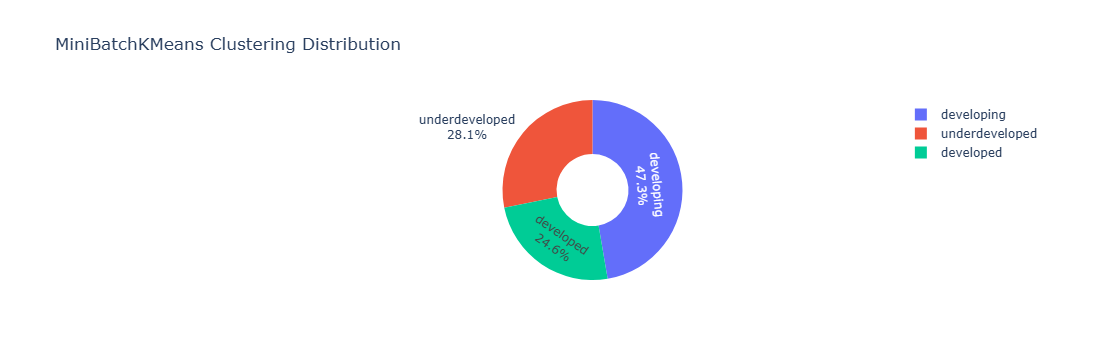

In [219]:
pie_data = df_final['mini_cluster'].value_counts()
pie_labels = pie_data.index
pie_values = pie_data.values

pie_fig = go.Figure(data=[go.Pie(labels=pie_labels, values=pie_values)])
pie_fig.update_traces(textinfo='percent+label', hole=0.4)
pie_fig.update_layout(title='MiniBatchKMeans Clustering Distribution')

pie_fig.show()

## PCA (Principal Component Analysis)

In [220]:
df_final.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster
country,,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,underdeveloped,underdeveloped,underdeveloped
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,underdeveloped,developing,developing
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,underdeveloped,developing,developing
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,underdeveloped,underdeveloped,underdeveloped
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,developing,developed,developing


In [221]:
df_for_pca=df_final.drop(columns=['k_means_cluster',	'hc_cluster',	'mini_cluster'],axis=1)

In [222]:
df_for_pca

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
country,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310


In [223]:
from sklearn.decomposition import PCA


pca = PCA(n_components = 2, random_state=42)
df_after_pca = pca.fit_transform(df_for_pca)

In [224]:
df_after_pca

array([[-1.98151280e+04,  1.65112472e+03],
       [-1.13389390e+04, -1.49346903e+03],
       [-8.92635259e+03, -3.26468410e+03],
       [-1.46524659e+04,  8.67795270e+02],
       [ 8.96142032e+02, -1.89847815e+03],
       [-6.99699306e+02, -3.00451171e+03],
       [-1.42839444e+04,  9.29672241e+01],
       [ 4.43727025e+04,  1.16354527e+04],
       [ 4.22463421e+04,  6.76525844e+03],
       [-5.72551309e+03, -4.39118182e+03],
       [ 1.45108648e+04,  6.97390702e+03],
       [ 2.27232733e+04, -1.08330393e+04],
       [-1.90710762e+04,  1.22994979e+03],
       [ 7.44735254e+02,  3.47340570e+03],
       [-5.44962091e+03, -4.39049953e+03],
       [ 3.90029276e+04,  6.39086337e+03],
       [-1.26570298e+04,  9.63440942e+01],
       [-1.95217046e+04,  1.65585861e+03],
       [-1.52018204e+04, -4.70524185e+02],
       [-1.60732239e+04,  7.79039217e+01],
       [-1.11343558e+04, -9.71315924e+02],
       [-7.33742276e+03, -2.16588186e+03],
       [-3.13382968e+03,  5.34572278e+02],
       [ 6.

In [225]:
# KMeans
k_means_pca = KMeans(n_clusters = 3, random_state=42)
k_means_pca.fit(df_after_pca)

KMeans(n_clusters=3, random_state=42)

In [226]:
k_means_pca.labels_

array([0, 0, 0, 0, 2, 2, 0, 1, 1, 0, 2, 2, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2,
       1, 0, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0,
       0, 2, 1, 0, 0, 0, 0, 1, 2, 2, 0, 1, 0, 2, 0, 0, 1, 0, 0, 2, 0, 0,
       0, 2, 2, 1, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 0, 1, 2, 0, 0, 0, 0, 0, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2,
       0, 1, 2, 2, 0, 0, 2, 2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 1, 2, 1, 2, 0, 0, 2, 0, 0, 0], dtype=int32)

In [227]:
df_final['PCA_k_means_cluster']=k_means_pca.labels_

In [230]:
df_final.head(25)
# 0=developing
# 1=underdeveloped
# 2=developed

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster,PCA_k_means_cluster
country,,,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,underdeveloped,underdeveloped,underdeveloped,underdeveloped
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,underdeveloped,developing,developing,underdeveloped
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,underdeveloped,developing,developing,underdeveloped
Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,underdeveloped,underdeveloped,underdeveloped,underdeveloped
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,developing,developed,developing,developing
Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,underdeveloped,developing,developing,developing
Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,underdeveloped,developing,developing,underdeveloped
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,developed,developed,developed,developed
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,developed,developed,developed,developed


In [231]:
df_final.PCA_k_means_cluster.replace(to_replace={0: 'developing',
                                  1: 'underdeveloped',
                                  0: 'developed'}, inplace=True)

In [232]:
df_final.head(25)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,k_means_cluster,hc_cluster,mini_cluster,PCA_k_means_cluster
country,,,,,,,,,,,,,
Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,underdeveloped,underdeveloped,underdeveloped,underdeveloped
Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,underdeveloped,developing,developing,underdeveloped
Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,underdeveloped,developing,developing,underdeveloped
Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,underdeveloped,underdeveloped,underdeveloped,underdeveloped
Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,developing,developed,developing,developing
Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,underdeveloped,developing,developing,developing
Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,underdeveloped,developing,developing,underdeveloped
Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,developed,developed,developed,developed
Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,developed,developed,developed,developed


## K-Means with PCA Results

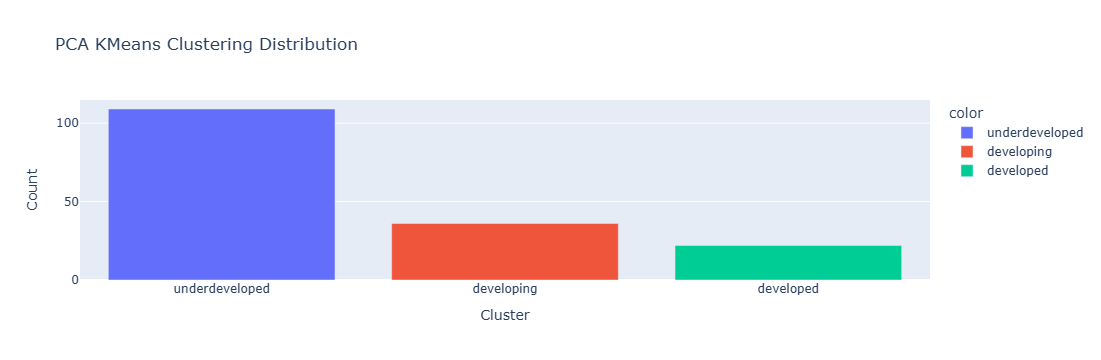

In [233]:
bar_fig = px.bar(
    df_final,
    x=df_final['PCA_k_means_cluster'].value_counts().index,
    y=df_final['PCA_k_means_cluster'].value_counts().values,
    color=df_final['PCA_k_means_cluster'].value_counts().index,
    title='PCA KMeans Clustering Distribution'
)

bar_fig.update_xaxes(title='Cluster')
bar_fig.update_yaxes(title='Count')

pio.show(bar_fig)

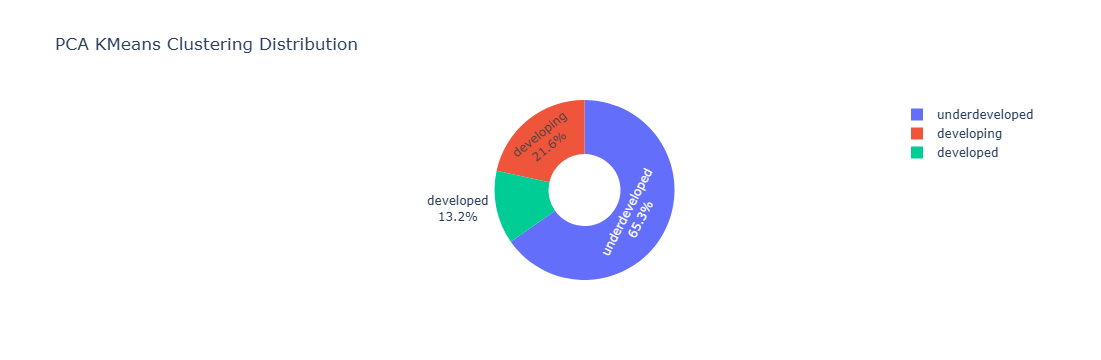

In [234]:
pie_data = df_final['PCA_k_means_cluster'].value_counts()
pie_labels = pie_data.index
pie_values = pie_data.values

pie_fig = go.Figure(data=[go.Pie(labels=pie_labels, values=pie_values)])
pie_fig.update_traces(textinfo='percent+label', hole=0.4)
pie_fig.update_layout(title='PCA KMeans Clustering Distribution')

pie_fig.show()

# Thanks